# Noise and Calibration

## Real qubits decohere, real gates have systematic errors, and real readouts are noisy. Before running anything serious, the device is *characterised* — its noise parameters measured — and *calibrated* to keep gates faithful. This notebook covers the standard noise model, the experiments that pin down its parameters, and the error-mitigation tricks that buy extra accuracy on NISQ hardware.

# 1. The cast of noise sources

## A few channels show up in *every* noise model. (Chapter 9 covers the formal framework; this is the hardware-flavoured version.)

## - **Amplitude damping ($T_1$).** Energy relaxation: $|1\rangle$ decays to $|0\rangle$ at rate $1/T_1$. Caused by spontaneous emission   into a lossy environment. Sets a hard ceiling on coherence.
## - **Pure dephasing ($T_\varphi$).** Random fluctuations in the qubit frequency wash out the relative phase between $|0\rangle$ and $|1\rangle$.
## - **Total dephasing ($T_2$).** Combined effect: $\frac{1}{T_2} = \frac{1}{2T_1} + \frac{1}{T_\varphi}$. Always $T_2 \leq 2 T_1$.
## - **Coherent errors.** Systematic miscalibration — over-/under-rotated pulses, frequency drift, off-resonant driving. These   are *invertible* and don't average out the way stochastic noise does.
## - **Crosstalk.** Pulse on qubit $i$ leaks into qubit $j$; or always-on $ZZ$ interaction between idle qubits accumulates phase.
## - **Leakage.** Population escapes to $|2\rangle$ outside the computational subspace. Especially relevant in transmons.
## - **Readout error.** Asymmetric (e.g. $P(1|0) \neq P(0|1)$) and correlated across qubits.

## Together these produce both **incoherent** and **coherent** errors. Different noise types call for different mitigation tools.

# 2. Measuring $T_1$ and $T_2$

## **$T_1$ experiment.** Prepare $|1\rangle$, wait time $\tau$, measure. The excited-state population decays as

$$ \Large  P_1(\tau) = e^{-\tau / T_1}. $$

## Fit an exponential to extract $T_1$.

## **$T_2^*$ (Ramsey) experiment.** Prepare $|+\rangle$, wait $\tau$, apply $H$, measure. Slow phase noise causes the fringe to dephase as

$$ \Large  P_0(\tau) = \tfrac{1}{2}(1 + e^{-\tau / T_2^*} \cos(\delta\omega\, \tau)). $$

## $T_2^*$ is sensitive to slow drift.

## **$T_2$ (Hahn echo) experiment.** Same as Ramsey but with an $X$ pulse in the middle of the wait time. This cancels low-frequency dephasing, giving the *intrinsic* $T_2$. Typically $T_2 \gg T_2^*$ when slow drift dominates.

## These three experiments are run automatically by the device backend on a fixed schedule. The numbers reported in IBM/Google data sheets are the latest fitted values.

True T1 = 80.0 us, fit T1 = 80.00 us


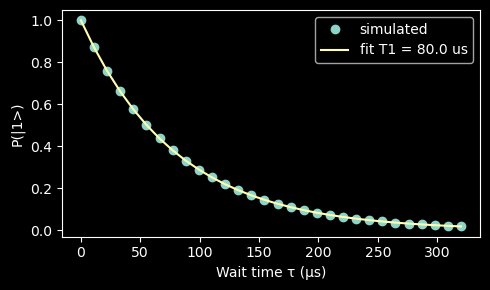

In [1]:
# Simulate a T1 experiment with a single-qubit amplitude-damping channel and recover T1 from a fit.
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

T1_true = 80.0     # microseconds

def amplitude_damping(rho, gamma):
    K0 = np.array([[1, 0], [0, np.sqrt(1 - gamma)]], dtype=complex)
    K1 = np.array([[0, np.sqrt(gamma)], [0, 0]], dtype=complex)
    return K0 @ rho @ K0.conj().T + K1 @ rho @ K1.conj().T

taus = np.linspace(0, 4 * T1_true, 30)
P1 = []
for tau in taus:
    rho = np.array([[0, 0], [0, 1]], dtype=complex)     # |1><1|
    gamma = 1 - np.exp(-tau / T1_true)                   # channel parameter
    rho = amplitude_damping(rho, gamma)
    P1.append(rho[1, 1].real)
P1 = np.array(P1)

# Fit P1 ~ exp(-tau / T1)
popt, _ = curve_fit(lambda t, T: np.exp(-t / T), taus, P1, p0=[60.0])
T1_fit = popt[0]
print(f'True T1 = {T1_true:.1f} us, fit T1 = {T1_fit:.2f} us')

plt.figure(figsize=(5, 3))
plt.plot(taus, P1, 'o', label='simulated')
plt.plot(taus, np.exp(-taus / T1_fit), label=f'fit T1 = {T1_fit:.1f} us')
plt.xlabel('Wait time τ (μs)'); plt.ylabel('P(|1>)'); plt.legend(); plt.tight_layout(); plt.show()

# 3. Randomized benchmarking and gate fidelity

## **Average gate fidelity** is what the data sheet reports. It is measured via **randomized benchmarking (RB)**:

## 1. Pick $m$ random Clifford gates $C_1, C_2, \dots, C_m$.
## 2. Compute $C_{m+1} = (C_m C_{m-1} \cdots C_1)^{-1}$ — the inversion that returns the state to $|0\rangle$.
## 3. Run the sequence $C_1 C_2 \cdots C_m C_{m+1}$ and measure $P(|0\rangle)$.
## 4. Sweep $m$ and fit

$$ \Large  P_{\mathrm{survival}}(m) = A\, p^m + B, \qquad F = 1 - \tfrac{d-1}{d}(1 - p), $$

## where $d = 2^n$ and $F$ is the average gate fidelity per Clifford.

## RB is **calibration-free in the inversion step** — every miscalibration ends up in the same exponential decay, so RB is robust to state-prep and measurement (SPAM) error. **Interleaved RB** measures the fidelity of one specific gate by interleaving it with random Cliffords.

## More refined techniques: **cycle benchmarking**, **direct fidelity estimation**, **gate set tomography** (full noise reconstruction).

# 4. Quantum volume and CLOPS

## A single fidelity number is too coarse to compare devices. Two whole-device benchmarks are common:

## ### Quantum Volume (QV)

## $\mathrm{QV} = 2^n$, where $n$ is the largest $n$ for which the device can run depth-$n$, width-$n$ random *model circuits* with mean heavy-output probability $\geq 2/3$. Sensitive to qubit count, connectivity, gate fidelity, *and* transpilation quality together.

## QV doubled roughly yearly through 2020s — Quantinuum H2 reached $2^{20}$ in 2024.

## ### CLOPS (Circuit Layer Operations Per Second)

## A *throughput* metric: how many circuit layers a device executes per second, including classical compilation and feedback. Important for variational algorithms (VQE/QAOA) that run thousands of parameter updates.

## Together QV and CLOPS form a 2D "size vs speed" snapshot. Neither alone tells the whole story.

# 5. Error mitigation (without full QEC)

## On NISQ devices, full quantum error *correction* is too expensive. But several **error-mitigation** techniques buy back accuracy at the cost of more shots or longer circuits:

## - **Measurement error mitigation.** Characterise the readout confusion matrix $M$ (run all $2^n$ basis prep + measure experiments), then invert: $\hat p = M^{-1} p_{\text{noisy}}$.
## - **Zero-noise extrapolation (ZNE).** Run the circuit at noise levels $1, 3, 5, \dots$ (by stretching pulses or duplicating gates). Extrapolate observed expectation values to "0 noise".
## - **Probabilistic error cancellation (PEC).** Express each gate's noise channel as a quasi-probability sum over Clifford circuits, then sample. Quadratic in shot cost but unbiased.
## - **Dynamical decoupling.** Insert echo pulses (X-Y-X-Y) during idle qubit time to cancel low-frequency dephasing — essentially free.
## - **Pauli twirling.** Conjugate each two-qubit gate with random Pauli pre/post-rotations. Turns coherent error into stochastic, which mitigation handles better.
## - **Symmetry verification.** If the algorithm preserves a symmetry (parity, particle number), discard shots that violate it.

## Most NISQ benchmark results combine 3–4 of these in the post-processing pipeline.

# 6. Calibration: what the device does for the user

## Modern devices run a continuous **calibration** loop in the background:

## - **Frequency tracking.** Re-tune each qubit's drive frequency to follow slow drift.
## - **Amplitude / DRAG calibration.** Re-tune single-qubit pulse amplitudes so that $X(\pi)$ is exactly $\pi$.
## - **Two-qubit gate retuning.** Periodically re-time / re-shape the CR or iSWAP pulses.
## - **Readout discriminator retraining.** Refresh the IQ-plane classifier as the resonator drifts.

## When a circuit is submitted, the latest calibration is automatically used. The user does not typically retune gates — but **knowing what calibrations exist** matters for debugging: a sudden fidelity drop is usually a calibration drift, not a hardware failure.

# Recap

## - **$T_1$, $T_2$**, gate fidelity, readout error, crosstalk, leakage — the standard noise vocabulary.
## - **Randomized benchmarking** is the field standard for fidelity; **QV** and **CLOPS** are whole-device benchmarks.
## - **Error mitigation** (ZNE, PEC, DD, twirling, readout inversion) is what NISQ algorithms actually use to extract usable expectation values.
## - **Calibration runs continuously in the background.** The user sees fresh-pulse circuits; a sudden fidelity drop usually means a drift.

## Next: how to actually submit a circuit to a real device and receive results — the IBM Quantum runtime, IonQ, Quantinuum, and the open-source SDKs that target them.